<a href="https://colab.research.google.com/github/Malaika-05/Programming-For-AI/blob/main/spam_email.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Email Spam Classifier

#1-Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("/content/mail_data.csv", encoding='latin-1')
df = df[['Category', 'Message']]
df.columns = ['label', 'text']

print(df.shape)
print(df.isnull().sum())
print(df['label'].value_counts())

(5572, 2)
label    0
text     0
dtype: int64
label
ham     4825
spam     747
Name: count, dtype: int64


encoding='latin-1' is used to correctly read special characters in the file.

#2️⃣ Exploratory Data Analysis (EDA)

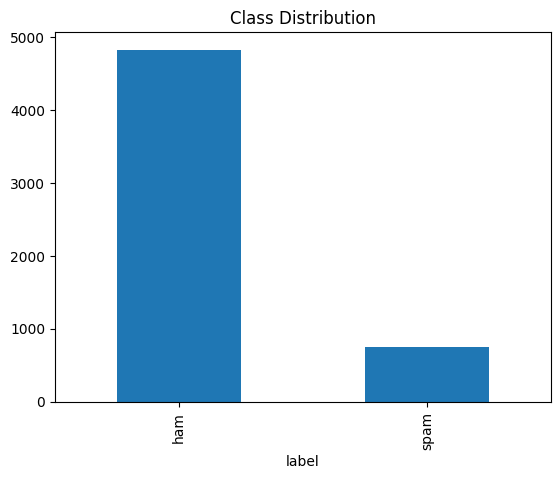

In [2]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

#Label Encoding

In [3]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

#3️⃣ Preprocessing

In [4]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()
    words = [ps.stem(w) for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


This code:

  .Cleans raw text by removing URLs, numbers,
  punctuation
  
  .Converts text to lowercase
  
  .Removes stopwords
  
  .Applies stemming to simplify words
  
  .Stores the final cleaned text in a new column for machine learning

#Feature Enrichment

In [5]:
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['digit_ratio'] = df['text'].apply(lambda x: sum(c.isdigit() for c in x) / len(x))

#TF-IDF Vectorization

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_text = tfidf.fit_transform(df['clean_text']).toarray()
X_extra = df[['char_count', 'word_count', 'digit_ratio']].values

X = np.hstack((X_text, X_extra))
y = df['label']

#Train-Test Split (Before SMOTE)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#Apply SMOTE (Balance ONLY Training Data)

In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train).value_counts())

After SMOTE: label
0    3859
1    3859
Name: count, dtype: int64


#Train Models

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

nb = MultinomialNB().fit(X_train, y_train)
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
svm = LinearSVC().fit(X_train, y_train)

#Evaluate

In [10]:
from sklearn.metrics import classification_report

def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))

evaluate("Naive Bayes", nb)
evaluate("Logistic Regression", lr)
evaluate("SVM", svm)

--- Naive Bayes ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       966
           1       0.80      0.96      0.87       149

    accuracy                           0.96      1115
   macro avg       0.90      0.96      0.93      1115
weighted avg       0.97      0.96      0.96      1115

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.93      0.93      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

--- SVM ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.93      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg  

Save Best Model

In [11]:
import joblib

joblib.dump(lr, "spam_model.pkl")
joblib.dump(tfidf, "vectorizer.pkl")

['vectorizer.pkl']